Shape Index Analysis against FRC gross parameters
Date of Last Update: 8.02.26

Shape index is based off an implicit curvature definition that can be found for various definitions of psi (flux). 

This code computes this shape index and plugs it back into internal_psi_stein_N, a geometric definition of flux in terms of shape index. From this, pressure, number density, flux lifetime, and instability growth rates are computed and compared against shape index.

In [1]:
from func_steinhaurer import *
from _functions4plasma import *

import math
import numpy as np 
import sympy as sp 
from scipy.optimize import root
import matplotlib.pyplot as plt 

# Define Variables
E0, E1, E2, E3 = sp.symbols("E:4")
B, r, z, a, b, X = sp.symbols('B r z a b X')
psi = sp.symbols('P')

### === External Psi
# Define Equations (for Eq. 2)
T1 = E0*(r**2/a**2)
T2 = E1*(r**2/a**2)*(r**2/a**2 - 4*z**2/a**2)
T3 = E2*(((E3*b + z)/((r**2 + (E3*b+z)**2)**0.5))+((E3*b - z)/((r**2 + (E3*b-z)**2)**0.5)))

psi         = sp.simplify((B*a**2)/2*(T1+T2+T3))
psi_r       = sp.diff(psi, r)
psi_rr      = sp.diff(psi_r, r)
psi_z       = sp.diff(psi, z)
psi_zz      = sp.diff(psi_z, z)
psi_rz      = sp.diff(psi_r, z)

# Define Functions
f_psi       = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi)
f_psi_r     = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_r)
f_psi_rr    = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_rr)
f_psi_z     = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_z)
f_psi_zz    = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_zz)
f_psi_rz    = sp.lambdify((B, E0, E1, E2, E3, r, z, a, b), psi_rz)


# Curvature based of Steinhaurer's analytical equation (Eq. 2)
def ext_curvature(B, E0, E1, E2, E3, r, z, a, b):
    num = f_psi_rr(B, E0, E1, E2, E3, r, z, a, b)*(f_psi_z(B, E0, E1, E2, E3, r, z, a, b))**2 - 2*f_psi_rz(B, E0, E1, E2, E3, r, z, a, b)*f_psi_r(B, E0, E1, E2, E3, r, z, a, b)*f_psi_z(B, E0, E1, E2, E3, r, z, a, b) + f_psi_zz(B, E0, E1, E2, E3, r, z, a, b)*(f_psi_r(B, E0, E1, E2, E3, r, z, a, b))**2
    den = ((f_psi_r(B, E0, E1, E2, E3, r, z, a, b))**2 + (f_psi_z(B, E0, E1, E2, E3, r, z, a, b))**2)**(1.5)
    return np.abs(num/den)

### === Internal Psi
i_psi       = ((3/2)**0.5)*((X*B*r**2)/2)*(1-(r**2/a**2)-(z**4/b**4)+1.5*(a**2/b**2))
i_psi_r     = sp.diff(i_psi, r)
i_psi_rr    = sp.diff(i_psi_r, r)
i_psi_z     = sp.diff(i_psi, z)
i_psi_zz    = sp.diff(i_psi_z, z)
i_psi_rz    = sp.diff(i_psi_r, z)

# Define Functions
fi_psi     = sp.lambdify((B, X, r, z, a, b), i_psi)
fi_psi_r   = sp.lambdify((B, X, r, z, a, b), i_psi_r)
fi_psi_rr  = sp.lambdify((B, X, r, z, a, b), i_psi_rr)
fi_psi_z   = sp.lambdify((B, X, r, z, a, b), i_psi_z)
fi_psi_zz  = sp.lambdify((B, X, r, z, a, b), i_psi_zz)
fi_psi_rz  = sp.lambdify((B, X, r, z, a, b), i_psi_rz)

# Curvature based of Steinhaurer's analytical equation (Eq. 2)
def int_curvature(B, X, r, z, a, b):
    num = fi_psi_rr(B, X, r, z, a, b)*(fi_psi_z(B, X, r, z, a, b))**2 - 2*fi_psi_rz(B, X, r, z, a, b)*fi_psi_r(B, X, r, z, a, b)*fi_psi_z(B, X, r, z, a, b) + fi_psi_zz(B, X, r, z, a, b)*(fi_psi_r(B, X, r, z, a, b))**2
    den = ((fi_psi_r(B, X, r, z, a, b))**2 + (fi_psi_z(B, X, r, z, a, b))**2)**(1.5)
    return np.abs(num/den)


In [2]:
Lconv = 1e3
acc = 100
# Parameters / Domain Definitions 
Rw          = 6.1/Lconv                 # Wall Radius [m]
Rc          = Rw
zLen        = 200/Lconv                 # Liner length [m]

B0          = 30
sig = f = 1.5                           # Flare parameter; adjustable parameter

T           = np.array([50])            # Temp in [eV]
TK          = T * eV/kb                 # Temp number in [K]

Rmax        = Rw                        # maximum r-domain value [m]
Rmin        = 0                         # minimum r-domain value [m]
Nr          = 1000                      # number of points in r-direction [\]
dr          = (Rmax - Rmin) / Nr        # radial differential [m]
Zmax        = zLen / 2                  # maximum z-domain value [m]
Zmin        = -zLen / 2                 # minimum z-domain value [m]
Nz          = 1000                      # number of points in z-direction [\]
dz          = (Zmax - Zmin) / Nz        # axial differential [m]
domx        = 1.4                       # domain multiplier to make plotting modifications easier
domy        = 0.8                       # domain multiplier to make plotting modifications easier
Rd          = Rmax * domx               # domain radius [m]
Zd          = Zmax * domy               # domain z-length [m]
r = np.arange(-Rd, Rd+dr, dr)
z = np.arange(-Zd, Zd+dz, dz)    
r_mesh, z_mesh = np.meshgrid(r, z, indexing='ij')


conI = True             # Varying Xs and Varying Elongation
conII = False           # Constant Xs and Varying Elongation
conIII = False          # Varying Xs and Constant Elongation

if conI:
    elong_arr   = np.linspace(1,10,num = acc)
    Xs_arr      = np.linspace(0.3, 0.9,num = acc)
    a_arr       = Rc*Xs_arr
    b_arr       =  np.multiply(a_arr, elong_arr)
    Bw_arr      = B0 / (1-(Xs_arr)**2)
elif conII:
    elong_arr   = np.linspace(1,10,num = acc)
    Xs          = 0.6
    a           = Rc*Xs
    b_arr       =  a*elong_arr
    Bw          = B0 / (1 - Xs**2)
elif conIII: 
    E           = 4.5
    Xs_arr      = np.linspace(0.3, 0.9,num = acc)
    a_arr       = Rc*Xs_arr
    b_arr       = a_arr*E
    Bw_arr = B0 / (1-(Xs_arr)**2)
else:
    sys.exit()

In [ ]:
### === Finding psi, then calculating shape index from psi
e_params    = []
mask = list(range(0, acc))

N_int_arr           = []
N_ext_arr           = []
psi_arr             = []                  
Br_ext_arr          = []
Br_int_arr          = []
Bz_ext_arr          = []
Bz_int_arr          = []

if conI:
    for i, E in enumerate(elong_arr):
        a   = a_arr[i]
        b   = b_arr[i]
        Xs  = Xs_arr[i]
        Bw  = Bw_arr[i]
        Br_int_arr.append((1/r_mesh) * internal_dpsi__dz_sporer(r_mesh, z_mesh, a, b, Bw, Xs))
        Bz_int_arr.append(-(1/r_mesh) * internal_dpsi__dr_sporer(r_mesh, z_mesh, a, b, Bw, Xs, f))

        initial_guess       = [Bw, Bw/3, Bw/5, 0.9]
        result              = root(external_E_params, initial_guess, args= (1/E, Xs, sig))

        if result.success: 
            E0, E1, E2, E3  = result.x
            e_params.append([E0, E1, E2, E3])
            psi_int         = internal_psi_sporer(r_mesh, z_mesh, a, b, Bw, Xs, f)
            psi_ext         = external_psi(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)

            inside = (psi_int > 0)
            psi_arr.append(np.where(inside, psi_int, psi_ext))                                  # is applied to create a full psi(r,z) [T*m^2]

            dpsi__dr_ext    = external_dpsi__dr(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)       # [T*m^2]; gradient of
            dpsi__dz_ext    = external_dpsi__dz(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)       # external magnetic flux
        
            Br_ext_arr.append(-(1/r_mesh) * dpsi__dz_ext)            # radial magnetic field [T]          #[T*m]
            Bz_ext_arr.append((1/z_mesh) * dpsi__dr_ext)             # axial magnetic field [T]

        else: 
            mask.remove(i)

    
    a_arr = a_arr[mask]
    b_arr = b_arr[mask]
    Xs_arr = Xs_arr[mask]
    Bw_arr = Bw_arr[mask]
    elong_arr= elong_arr[mask]

    mask = []
    for i, E in enumerate(elong_arr):
        a   = a_arr[i]
        b   = b_arr[i]
        Xs  = Xs_arr[i]
        Bw  = Bw_arr[i]
        e0, e1, e2, e3 = e_params[i]

        K_ext = (ext_curvature(Bw, e0, e1, e2, e3, a, 0, a, b))
        if math.isnan(K_ext):
            pass
        else:
            N_ext_arr.append(shape_index(a, b, K_ext))
            N_int_arr.append(shape_index(a, b, int_curvature(Bw, Xs, a, 0, a, b)))
            mask.append(i)
    
    N_elong_arr = elong_arr[mask]


elif conII: 
    for i, E in enumerate(elong_arr):
        b   = b_arr[i]
        Br_int_arr.append((1/r_mesh) * internal_dpsi__dz_sporer(r_mesh, z_mesh, a, b, Bw, Xs))
        Bz_int_arr.append(-(1/r_mesh) * internal_dpsi__dr_sporer(r_mesh, z_mesh, a, b, Bw, Xs, f))

        initial_guess       = [Bw, Bw/3, Bw/5, 0.9]
        result              = root(external_E_params, initial_guess, args= (1/E, Xs, sig))

        if result.success: 
            E0, E1, E2, E3  = result.x
            e_params.append([E0, E1, E2, E3])
            psi_int         = internal_psi_sporer(r_mesh, z_mesh, a, b, Bw, Xs, f)
            psi_ext         = external_psi(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)

            inside          = (psi_int > 0)
            psi_arr.append(np.where(inside, psi_int, psi_ext))

            dpsi__dr_ext    = external_dpsi__dr(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)         #[T*m^2]; gradient of
            dpsi__dz_ext    = external_dpsi__dz(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)         #external magnetic flux
        
            Br_ext_arr.append(-(1/r_mesh) * dpsi__dz_ext)            # radial magnetic field [T]          #[T*m]
            Bz_ext_arr.append((1/z_mesh) * dpsi__dr_ext)             # axial magnetic field [T]
        else: 
            mask.remove(i)

    b_arr = b_arr[mask]
    elong_arr= elong_arr[mask]

elif conIII:
    for i, Xs in enumerate(Xs_arr):
        a   = a_arr[i]
        b   = b_arr[i]
        Bw  = Bw_arr[i]
        Br_int_arr.append((1/r_mesh) * internal_dpsi__dz_sporer(r_mesh, z_mesh, a, b, Bw, Xs))
        Bz_int_arr.append(-(1/r_mesh) * internal_dpsi__dr_sporer(r_mesh, z_mesh, a, b, Bw, Xs, f))

        initial_guess = [Bw, Bw/3, Bw/5, 0.9]
        result = root(external_E_params, initial_guess, args= (1/E, Xs, sig))

        if result.success: 
            E0, E1, E2, E3 = result.x
            e_params.append([E0, E1, E2, E3])
            psi_int         = internal_psi_sporer(r_mesh, z_mesh, a, b, Bw, Xs, f)
            psi_ext         = external_psi(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)

            inside = (psi_int > 0)
            psi_arr.append(np.where(inside, psi_int, psi_ext))  

            dpsi__dr_ext = external_dpsi__dr(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)         #[T*m^2]; gradient of
            dpsi__dz_ext = external_dpsi__dz(r_mesh, z_mesh, Bw, a, b, E0, E1, E2, E3)         #external magnetic flux
        
            Br_ext_arr.append(-(1/r_mesh) * dpsi__dz_ext)            # radial magnetic field [T]          #[T*m]
            Bz_ext_arr.append((1/z_mesh) * dpsi__dr_ext)             # axial magnetic field [T]
        else: 
            mask.remove(i)

    a_arr = a_arr[mask]
    b_arr = b_arr[mask]
    Xs_arr = Xs_arr[mask]
    Bw_arr = Bw_arr[mask]


[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(na

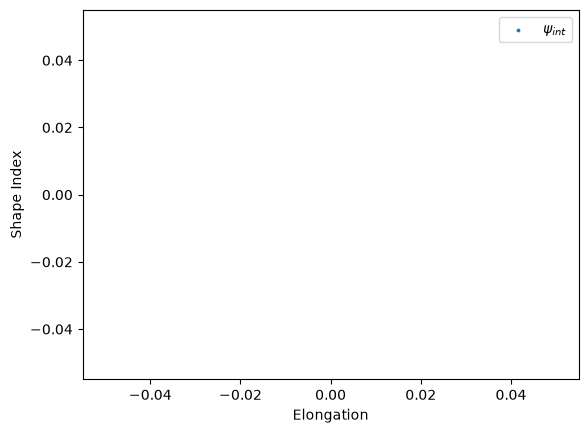

In [ ]:
### === Plotting 

# Figure 0 - Shape Index vs Elongation 
fig0, ax0 = plt.subplots()
ax0.scatter(N_elong_arr, N_int_arr, s=3, label = r"$\psi_{int}$")
# ax0.scatter(N_elong_arr, N_ext_arr, s=3, label = r"$\psi_{ext}$")

ax0.legend()
ax0.set_xlabel("Elongation")
ax0.set_ylabel("Shape Index")
plt.show()